In [1]:
def getDist(cord1,cord2):
    return (
        (float(cord1[0])-float(cord2[0]))**2+
        (float(cord1[1])-float(cord2[1]))**2+
        (float(cord1[2])-float(cord2[2]))**2)**0.5 * 10

class gro:    # ndx = {chineID : (start atomNdx, end atomNdx)}
    def __init__(self, groFile, proAtomNdx, ligAtomNdx):
        from tqdm import tqdm
        self.version = "groObj V.2"
        self.type = "Multi Chains"
        with open(groFile, "r") as gro:
            groLines = gro.readlines()
            self.atomNum = groLines[1]
        self.frames = {} # { frameNdx : { atomNdx : { resNdx : x, coord : (x, y, x) } } }
        frameNdx = 0
        atomDic = {}
        resNdx = groLines[2].split()[:-3]
        for line in tqdm(groLines[2:]):
            line_list = line.split()
            if len(line_list) == 3:
                self.frames[frameNdx] = atomDic
                # self.getResData(frameNdx)
                frameNdx = frameNdx + 1
                atomDic = {}
            elif "Title" not in line and len(line.split()) > 3:
                #print(line)
                atomNdx = int(line.split()[2])
                atomDic[atomNdx] = {
                    "resNdx" : int(line.split()[0][:-3]),
                    "coord" : (
                        float(line.split()[3]),
                        float(line.split()[4]),
                        float(line.split()[5])
                    )
                }
        print("> getting resData")
        resData = {
            "proRes": self.getRes(ndx=proAtomNdx),
            "ligRes": self.getRes(ndx=ligAtomNdx)
            }
        import pickle
        print("> saving resData")
        with open("resData.pkl", "wb") as resDataF:
            pickle.dump(resData, resDataF)
    def getRes(self, ndx):
        frameDic = {} # { frameNdx : { resNdx : { atomNdx : (coord) } } }
        for frame in self.frames.items():# { frameNdx : { atomNdx : { resNdx : x, coord : (x, y, x) } } }
            frameNdx = frame[0]
            atomDic = frame[1]
            resDic = {}
            for atomNdx in range(ndx[0], ndx[1]+1):
                resNdx = atomDic[atomNdx]["resNdx"]
                coord = atomDic[atomNdx]["coord"]
                if resNdx not in list(resDic.keys()):
                    resDic[resNdx] = [coord]
                else:
                    resDic[resNdx].append(coord)
            frameDic[frameNdx] = resDic
        return frameDic
    # def getResData(self, frameNdx):
    #     import pickle as pkl
    #     proAtomNdx = (1, 1603)
    #     ligAtomNdx = (2864, 2936)
    #     proRes = self.getRes(proAtomNdx)[frameNdx]
    #     ligRes = self.getRes(ligAtomNdx)[frameNdx]
    #     data = {
    #         "frameNdx": frameNdx,
    #         "proRes": proRes,
    #         "ligRes": ligRes
    #         }
    #     with open(f"./framesPkls/{frameNdx}.pkl", "wb") as dataFile:
    #         pkl.dump(data, dataFile)
    #     return 1

def contactPerFrame(frameNdx, proAtomNdx, ligAtomNdx, groObj):
    import pandas as pd
    import pickle
    print("> start")
    with open(groObj, "rb") as groDataFile:
        groData = pickle.load(groDataFile)
    print("> read done")
    ligRes = groData.getRes(ligAtomNdx)[frameNdx]
    proRes = groData.getRes(proAtomNdx)[frameNdx]
    #print(proRes[15])
    print("> getRes done")
    distDic = {}
    ligCoords = []
    for coord in ligRes.items():
        ligCoords = ligCoords + coord[1]
    print("> ligCoords get done")
    for resID in proRes.keys():
        tmpDislist = []
        for resCoords in proRes[resID]:
            for ligCoord in ligCoords:
                #print(resAtom)
                tmpDislist.append(
                    getDist(resCoords, ligCoord)
                )
        distDic[resID] = round(min(tmpDislist), 3)
    print("clt done")
    #print(distDic)
    distDic["frameNdx"] = frameNdx
    dataFrame = pd.DataFrame([distDic])
    return dataFrame

def contactPerFrame_v2(frameNdx, alert = 0):
    import pandas as pd
    import pickle
    if alert: print("> start")
    with open(f"./resData.pkl", "rb") as resDataF:
        resData = pickle.load(resDataF)
    if alert: print("> read done")
    ligRes = resData["ligRes"][frameNdx]
    proRes = resData["proRes"][frameNdx]
    # print("> getRes done")
    distDic = {}
    ligCoords = []
    for coord in ligRes.items():
        ligCoords = ligCoords + coord[1]
    if alert: print("> ligCoords get done")
    for resID in proRes.keys():
        tmpDislist = []
        for resCoords in proRes[resID]:
            for ligCoord in ligCoords:
                #print(resAtom)
                tmpDislist.append(
                    getDist(resCoords, ligCoord)
                )
        distDic[resID] = round(min(tmpDislist), 3)
    if alert: print("> clt done")
    distDic["frameNdx"] = frameNdx
    dataFrame = pd.DataFrame([distDic])
    return dataFrame

In [2]:
groData = gro("../3_md/trjconv/fit.gro", (1, 1603), (2864, 2936))
import pickle
with open("groData.pkl", "wb") as groDataFile:
    pickle.dump(groData, groDataFile)

100%|██████████| 14697937/14697937 [05:28<00:00, 44677.55it/s]


> getting resData
> saving resData


In [1]:
import pickle as pkl
with open("./resData.pkl", "rb") as resDataF:
    resData = pkl.load(resDataF)

In [3]:
resData["proRes"][0]

{15: [(4.938, 2.931, 3.049),
  (4.837, 2.916, 3.066),
  (4.98, 2.836, 3.053),
  (4.939, 2.975, 2.955),
  (5.012, 3.014, 3.148),
  (5.001, 2.97, 3.246),
  (5.156, 3.048, 3.108),
  (5.188, 3.005, 3.011),
  (5.215, 2.985, 3.179),
  (5.206, 3.197, 3.139),
  (5.177, 3.227, 3.242),
  (5.164, 3.267, 3.064),
  (5.358, 3.218, 3.105),
  (5.375, 3.328, 3.105),
  (5.373, 3.173, 3.005),
  (5.439, 3.153, 3.21),
  (5.409, 3.125, 3.301),
  (5.573, 3.14, 3.201),
  (5.648, 3.205, 3.115),
  (5.617, 3.268, 3.044),
  (5.746, 3.193, 3.126),
  (5.641, 3.077, 3.296),
  (5.58, 3.016, 3.347),
  (5.738, 3.06, 3.282),
  (4.935, 3.141, 3.167),
  (4.906, 3.209, 3.064)],
 16: [(4.904, 3.18, 3.292),
  (4.921, 3.124, 3.372),
  (4.844, 3.306, 3.323),
  (4.747, 3.305, 3.276),
  (4.821, 3.315, 3.48),
  (4.774, 3.414, 3.495),
  (4.925, 3.329, 3.516),
  (4.724, 3.212, 3.546),
  (4.64, 3.173, 3.485),
  (4.686, 3.254, 3.641),
  (4.808, 3.09, 3.592),
  (4.85, 3.083, 3.708),
  (4.828, 2.998, 3.506),
  (4.901, 3.427, 3.273),
  

In [5]:
contactPerFrame_v2(0, 1)

> start
> read done
> ligCoords get done
> clt done


,15,16,17,18,19,20,21,22,23,24,...,107,108,109,110,111,112,113,114,115,frameNdx
0,14.583,13.6,11.07,6.499,3.643,9.554,9.885,3.598,6.807,2.631,...,3.299,2.086,3.368,3.34,5.068,8.729,9.572,10.346,12.289,0


In [6]:
from joblib import Parallel, delayed
from tqdm import tqdm
import pickle
import pandas as pd
results = Parallel(
    n_jobs=80, backend='multiprocessing'
    )(delayed(contactPerFrame_v2)(frameNdx, 0) for frameNdx in tqdm(range(0,5001)))
results = pd.concat(results, axis=0, ignore_index=True)
results = results.sort_values(by=results.columns[-1], ascending=True)
with open("con_results.pkl", "wb") as con_results:
    pickle.dump(results, con_results)


100%|██████████| 5001/5001 [08:47<00:00,  9.48it/s]


In [3]:
import pickle
with open("con_results.pkl", "wb") as con_results:
    pickle.dump(results, con_results)

In [1]:
import pickle
import pandas as pd
with open("con_results.pkl", "rb") as con_results:
    results = pickle.load(con_results)
(results)

,15,16,17,18,19,20,21,22,23,24,...,107,108,109,110,111,112,113,114,115,frameNdx
0,14.583,13.600,11.070,6.499,3.643,9.554,9.885,3.598,6.807,2.631,...,3.299,2.086,3.368,3.340,5.068,8.729,9.572,10.346,12.289,0
1,13.377,12.574,7.922,5.586,3.816,8.071,9.507,2.083,5.688,2.094,...,4.375,1.668,4.155,4.066,7.949,9.885,11.664,12.178,13.815,1
2,12.087,10.752,8.089,5.205,2.750,8.126,9.244,3.138,6.130,2.695,...,2.927,2.432,5.600,6.232,8.874,11.477,11.938,12.421,14.583,2
3,12.165,11.210,7.859,5.305,2.728,7.936,8.642,4.056,5.824,2.255,...,3.568,2.503,5.990,4.796,8.777,11.448,12.340,12.373,13.619,3
4,11.892,11.487,7.097,3.813,2.656,8.397,9.572,3.674,6.567,2.457,...,3.728,2.037,5.288,5.762,9.017,10.287,12.622,12.790,14.646,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4996,18.403,14.877,11.526,9.955,4.247,9.674,10.870,5.812,5.911,2.006,...,6.960,5.724,8.826,7.865,9.452,13.364,13.850,13.820,15.919,4996
4997,17.884,15.579,11.220,9.767,4.360,9.511,11.063,5.668,6.534,2.826,...,3.862,3.454,7.541,9.162,9.275,13.158,13.746,13.873,15.293,4997
4998,18.286,16.035,12.732,10.529,4.598,9.457,11.050,6.124,6.777,2.378,...,4.807,4.746,7.105,8.661,9.673,14.310,14.961,14.597,16.584,4998
4999,18.076,15.039,12.357,10.501,4.788,9.504,11.160,5.978,6.341,2.540,...,4.490,3.482,8.074,9.542,10.238,14.759,15.274,14.823,16.747,4999


In [2]:
heatDat = results.iloc[:, :-1].T
heatDat

,0,1,2,3,4,5,6,7,8,9,...,4991,4992,4993,4994,4995,4996,4997,4998,4999,5000
15,14.583,13.377,12.087,12.165,11.892,12.328,12.816,12.400,13.702,11.619,...,17.315,18.251,18.780,18.183,17.857,18.403,17.884,18.286,18.076,17.875
16,13.600,12.574,10.752,11.210,11.487,11.646,10.698,10.104,11.557,10.106,...,14.461,14.932,15.271,14.836,14.836,14.877,15.579,16.035,15.039,14.350
17,11.070,7.922,8.089,7.859,7.097,8.224,6.647,6.193,7.671,6.054,...,11.598,11.975,11.690,11.461,10.511,11.526,11.220,12.732,12.357,12.241
18,6.499,5.586,5.205,5.305,3.813,5.242,4.328,5.218,5.720,4.415,...,9.715,10.334,9.923,10.048,9.344,9.955,9.767,10.529,10.501,10.146
19,3.643,3.816,2.750,2.728,2.656,2.974,2.569,2.641,2.877,2.959,...,4.040,4.276,4.823,3.970,3.727,4.247,4.360,4.598,4.788,3.988
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
111,5.068,7.949,8.874,8.777,9.017,9.978,8.691,8.178,8.237,7.995,...,9.394,8.884,9.082,7.344,9.504,9.452,9.275,9.673,10.238,10.109
112,8.729,9.885,11.477,11.448,10.287,10.507,11.196,10.944,11.575,10.927,...,13.426,12.889,12.493,11.907,13.800,13.364,13.158,14.310,14.759,13.936
113,9.572,11.664,11.938,12.340,12.622,12.643,12.571,12.624,12.090,11.973,...,13.317,13.118,11.893,12.153,14.961,13.850,13.746,14.961,15.274,14.489
114,10.346,12.178,12.421,12.373,12.790,12.535,12.863,13.394,13.284,12.770,...,12.536,13.151,11.644,13.148,15.051,13.820,13.873,14.597,14.823,13.902


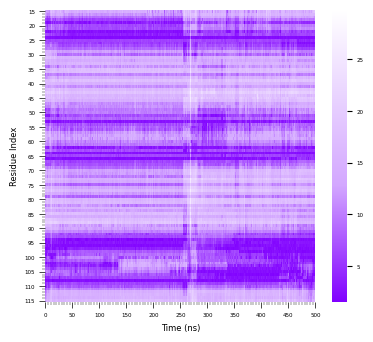

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.ticker as ticker

df = heatDat

# 创建自定义颜色映射
# 5以下颜色越小越深，大于等于5的白色
cmap = mcolors.LinearSegmentedColormap.from_list(
    "custom_cmap",
    [(0, "#8000FF"), (0.4, "#D3A7FF"), (1, "#ffffff")],
    N=512
)

# 绘制热图
fig, ax = plt.subplots(figsize=(4, 3.5) )  # 设置图形大小
sns.heatmap(df, annot=False, cmap=cmap)#, norm=norm, fmt=".1f", cbar_kws=cbar_kws)  # 设置颜色条的标签

major_pos   = range(0, 5001, 500)
major_label = range(0, 501, 50)
minor_pos   = range(0, 5001, 50)

plt.xticks(major_pos, major_label, rotation=0)
ax.xaxis.set_minor_locator(ticker.FixedLocator(minor_pos))
ax.tick_params(axis="x", which="major", direction="out", width=0.5, length=4, right=False,labelsize=4)
ax.tick_params(axis="x", which="minor", direction="out", width=0.3, length=2, right=False)

plt.yticks([x+0.5 for x in range(0, 101, 5)], range(15, 116, 5))
ax.tick_params(axis="y",reset=True, which="both", direction="out", width=0.5, length=4,labelsize=4,right=False)
ax.tick_params(axis="y", which="minor",reset=True, direction="out", width=0.3, length=2,zorder=1,right=False)

ax.yaxis.set_minor_locator(ticker.AutoMinorLocator(5))


cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=4)  # 设置颜色条刻度的字体大小

plt.tight_layout(pad=1.5)

plt.ylabel("Residue Index", fontsize=6)
plt.xlabel("Time (ns)", fontsize=6)

plt.savefig("HeatMap_PAC5_3.png", dpi=600)
plt.savefig("HeatMap_PAC5_3.svg", dpi=600)
# plt.savefig("HeatMap_test.pdf", dpi=600)
# plt.savefig("HeatMap_test.svg", dpi=600)

plt.show()
